### Exercise 14.1
Install and run the OG-Core example file as instructed above on your computer. How long did it take to execute?

Answer: 

I installed OG-Core using the instructions in the training manual.

Activated the ogcore-dev conda environment

Navigated to the examples directory in my OG-Core folder

Ran the example script using:

python run_ogcore_example.py


The model completed both the baseline and reform simulations successfully.
All expected output files were generated.

Execution time (reported by /usr/bin/time -v):

Baseline simulation: ~16,789 seconds (≈ 4.66 hours)

Reform simulation: ~14,252 seconds (≈ 3.96 hours)

Total time: ~31,052 seconds (≈ 8 hours 37 minutes 46 seconds)


In [10]:
import sys, os
print("Python executable:", sys.executable)
print("Notebook sees WSL files? ->", os.path.exists("/home/rachi_allick/OG-Core/run_full_example_transcript.txt"))

Python executable: c:\Users\Prachi Mallick\.conda\envs\ogcore-dev\python.exe
Notebook sees WSL files? -> True


In [11]:
import pandas as pd
csv_path = "/home/rachi_allick/OG-Core/examples/OG-Core-Example/OG-Core_example_output.csv"
df = pd.read_csv(csv_path, index_col=0)
df.head()


,Variable,2021,2022,2023,2024,2025,2026,2027,2028,2029,2030,2021-2030,SS
0,GDP ($Y_t$),-0.166356,-0.140401,-0.218056,-0.223965,-0.211837,-0.187752,-0.161628,-0.123865,-0.097603,-0.069471,-0.161728,-0.386144
1,Consumption ($C_t$),-0.075300,1.046807,0.130098,-0.126457,-0.243844,-0.324191,-0.367050,-0.422280,-0.431320,-0.437607,-0.122004,-0.717665
2,Capital Stock ($K_t$),-0.373272,-0.408493,-0.656561,-0.729016,-0.749174,-0.738536,-0.711576,-0.644660,-0.596277,-0.540108,-0.615419,-1.506782
3,Labor ($L_t$),-0.054761,0.004254,0.018863,0.049048,0.078702,0.110088,0.135757,0.157691,0.171948,0.184869,0.082355,0.222549
4,Real interest rate ($r_t$),-3.050776,-2.943980,-2.639766,-2.521710,-2.465373,-2.451001,-2.452789,-2.579737,-2.609287,-2.652481,-2.639310,-1.402195


In [12]:
from ogcore.utils import safe_read_pickle
base_ss = safe_read_pickle("/home/rachi_allick/OG-Core/OUTPUT_BASELINE/SS/SS_vars.pkl")
base_tpi = safe_read_pickle("/home/rachi_allick/OG-Core/examples/OG-Core-Example/OUTPUT_BASELINE/TPI/TPI_vars.pkl")
reform_ss = safe_read_pickle("/home/rachi_allick/OG-Core/examples/OG-Core-Example/OUTPUT_REFORM/SS/SS_vars.pkl")
reform_tpi = safe_read_pickle("/home/rachi_allick/OG-Core/examples/OG-Core-Example/OUTPUT_REFORM/TPI/TPI_vars.pkl")

print("Keys in baseline SS:", sorted(base_ss.keys()))
print("Keys in baseline TPI:", sorted(base_tpi.keys()))
print("Keys in reform SS:", sorted(reform_ss.keys()))
print("Keys in reform TPI:", sorted(reform_tpi.keys()))

Keys in baseline SS: ['B', 'BQ', 'C', 'C_i', 'D', 'D_d', 'D_f', 'G', 'I', 'I_d', 'I_g', 'I_total', 'K', 'K_d', 'K_f', 'K_g', 'K_m', 'L', 'L_m', 'RM', 'TR', 'UBI', 'Y', 'Y_m', 'agg_pension_outlays', 'b_s', 'b_sp1', 'before_tax_income', 'bequest_tax', 'bequest_tax_revenue', 'bq', 'business_tax_revenue', 'c', 'c_i', 'cons_tax_revenue', 'debt_service', 'debt_service_f', 'etr', 'euler_labor_leisure', 'euler_savings', 'factor', 'hh_net_taxes', 'iit_payroll_tax_revenue', 'iit_revenue', 'mtrx', 'mtry', 'n', 'new_borrowing', 'new_borrowing_f', 'p_i', 'p_m', 'p_tilde', 'payroll_tax_revenue', 'pension_benefits', 'r', 'r_gov', 'r_p', 'resource_constraint_error', 'rm', 'sales_tax', 'theta', 'total_government_outlays', 'total_primary_government_outlays', 'total_tax_revenue', 'tr', 'ubi', 'w', 'wealth_tax', 'wealth_tax_revenue']
Keys in baseline TPI: ['B', 'BQ', 'C', 'C_i', 'D', 'D_d', 'D_f', 'G', 'I', 'I_d', 'I_g', 'I_total', 'K', 'K_d', 'K_f', 'K_g', 'K_m', 'L', 'L_m', 'RM', 'TR', 'UBI', 'Y', 'Y_m'

In [13]:
import re
from pathlib import Path

transcript = Path("/home/rachi_allick/OG-Core/run_full_example_transcript.txt")
log = Path("/home/rachi_allick/OG-Core/run_example_log.txt")

def find_seconds_in_text(text):
    # regex to catch floats followed by 'seconds' or 'sec' or 's' or after 'It took' or 'run time'
    patterns = [
        r"It took ([0-9]+(?:\.[0-9]+)?) seconds",
        r"total time was\s+([0-9]+(?:\.[0-9]+)?)",
        r"run time =\s*([0-9]+(?:\.[0-9]+)?)",
        r"took ([0-9]+(?:\.[0-9]+)?) seconds",
        r"(\d+(?:\.\d+)?) seconds"
    ]
    got = []
    for pat in patterns:
        for m in re.finditer(pat, text, flags=re.IGNORECASE):
            try:
                got.append(float(m.group(1)))
            except:
                pass
    return got

def parse_file(p):
    if not p.exists():
        return []
    txt = p.read_text(errors="ignore")
    seconds = find_seconds_in_text(txt)
    return seconds

sec_t = parse_file(transcript)
sec_l = parse_file(log)

print("Seconds found in transcript:", sec_t)
print("Seconds found in log:", sec_l)

# heuristics to print likely baseline/reform/total:
# from your run we expect numbers ~ 16000 (baseline), ~14000 (reform), ~31052 (total)
all_found = sec_t + sec_l
all_found_sorted = sorted(set(all_found))
print("All parsed unique seconds (sorted):", all_found_sorted)

# If we find 2 or 3 numbers, print friendly guess:
if len(all_found_sorted) >= 3:
    print("Likely baseline (largest of the two separate runs?), reform (second):",
          all_found_sorted[-3:], " — pick the numbers that match ~16000, ~14000, and ~31000")


Seconds found in transcript: []
Seconds found in log: [16789.87662935257, 14252.378679275513, 31052.951018333435, 16789.88293814659, 14252.383257865906, 16789.87662935257, 14252.378679275513, 16789.87662935257, 14252.378679275513]
All parsed unique seconds (sorted): [14252.378679275513, 14252.383257865906, 16789.87662935257, 16789.88293814659, 31052.951018333435]
Likely baseline (largest of the two separate runs?), reform (second): [16789.87662935257, 16789.88293814659, 31052.951018333435]  — pick the numbers that match ~16000, ~14000, and ~31000


In [14]:
import math
def nice(seconds):
    s = int(round(seconds))
    h = s//3600
    m = (s%3600)//60
    sec = s%60
    return f"{h}h {m}m {sec}s"

# example: replace with the numbers you find
seconds_example = 31052.95
print("Example total:", nice(seconds_example))

Example total: 8h 37m 33s


### Exercise 15.1
 Using the above code blocks as an example, simulate the effects of a change in the corporate income tax rate (note the default in OG-Core is 21%). Just simulate the effects on the steady state (see the keyword arguments to the runner function). Warning: OG-Core allows the corporate income tax rate to vary over time and across industries, so you will need to enter it as a list of lists (even if it’s just a scalar that applies to all industries and time).


In [15]:
import ogcore

# Create baseline parameter object
p_base = ogcore.parameters.Specifications(
    output_base='./OUTPUT_BASELINE',
    baseline=True
)

# Solve steady state only
ss_base = ogcore.SS.run_SS(p_base)
print("Baseline SS complete.")

SS using initial guess factors for r and TR of 1.0 and 1.0 respectively.
GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e-04', '-3.462e-02']
GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e-04', '-3.462e-02']
GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e-04', '-3.462e-02']
GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e-04', '-3.462e-02']
GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', 

Baseline SS complete.


\\wsl.localhost\Ubuntu\home\rachi_allick\OG-Core\ogcore\SS.py:1568: UserWarning: Warning: The combination of the tax policy you specified and your target debt-to-GDP ratio results in an infeasible amount of government spending in order to close the budget (i.e., G < 0)
  warnings.warn(


In [1]:
import pickle, builtins, numpy as np, pprint

base_path = r"C:\Users\Prachi Mallick\Downloads\OG-Core-Results\TPI_vars_baseline.pkl"
reform_path = r"C:\Users\Prachi Mallick\Downloads\OG-Core-Results\TPI_vars_reform.pkl"

tpi_base = pickle.load(builtins.open(base_path, "rb"))
tpi_reform = pickle.load(builtins.open(reform_path, "rb"))

print("BASE keys (first 30):")
pprint.pprint(list(tpi_base.keys())[:30])

# quick dims example
print("Y shape (base):", np.array(tpi_base['Y']).shape)
print("K shape (base):", np.array(tpi_base['K']).shape)


BASE keys (first 30):
['Y',
 'B',
 'K',
 'K_f',
 'K_d',
 'L',
 'C',
 'I',
 'I_total',
 'I_d',
 'K_g',
 'I_g',
 'BQ',
 'RM',
 'Y_m',
 'K_m',
 'L_m',
 'C_i',
 'TR',
 'agg_pension_outlays',
 'G',
 'UBI',
 'total_government_outlays',
 'total_primary_government_outlays',
 'total_tax_revenue',
 'business_tax_revenue',
 'iit_payroll_tax_revenue',
 'iit_revenue',
 'payroll_tax_revenue',
 'bequest_tax_revenue']
Y shape (base): (320,)
K shape (base): (320,)


In [17]:
import numpy as np
from ogcore import execute, parameters

p_reform = parameters.Specifications(output_base = './OUTPUT_REFORM', baseline = False)

# Try direct assignment (list-of-lists). This often works and bypasses paramtools validation.
p_reform.business_tax_rates = [[0.15]]

# Run SS only (avoid TPI dependency)
execute.runner(p_reform, time_path=False)


Using previous solutions for SS


making dir:  ./OUTPUT_REFORM\SS
making dir:  ./OUTPUT_REFORM\TPI
In runner, baseline is  False


GE loop errors = ['6.908e-12', '7.218e-12', '-4.092e-11', '0.000e+00', '3.264e-10', '4.445e-12', '6.659e-12', '8.176e-12', '4.878e-12', '6.035e-12', '7.359e-12', '1.504e-12', '2.938e-11']
GE loop errors = ['6.909e-12', '7.218e-12', '-4.092e-11', '0.000e+00', '3.264e-10', '4.445e-12', '6.659e-12', '8.176e-12', '4.878e-12', '6.035e-12', '7.359e-12', '1.504e-12', '2.938e-11']
GE loop errors = ['6.908e-12', '7.218e-12', '-4.092e-11', '0.000e+00', '3.264e-10', '4.445e-12', '6.659e-12', '8.176e-12', '4.878e-12', '6.035e-12', '7.359e-12', '1.504e-12', '2.938e-11']
GE loop errors = ['-1.459e-09', '-6.699e-10', '3.797e-09', '0.000e+00', '1.738e-09', '1.114e-10', '1.489e-10', '1.496e-10', '8.866e-11', '1.033e-10', '1.405e-10', '3.139e-11', '1.565e-10']
GE loop errors = ['6.909e-12', '-9.293e-10', '-4.092e-11', '0.000e+00', '3.264e-10', '4.445e-12', '6.659e-12', '8.176e-12', '4.878e-12', '6.035e-12', '7.359e-12', '1.504e-12', '2.938e-11']
GE loop errors = ['-7.805e-10', '-8.154e-10', '-1.293e-08'

JUST SAVED SS output to  ./OUTPUT_REFORM\SS\SS_vars.pkl
It took 14.139721155166626 seconds to get that part done.


In [28]:
# Cell: load baseline & reform pickles (adjust paths if you used different names)
import os, pickle, builtins, pandas as pd, numpy as np

wdir = r'C:\Users\Prachi Mallick\Downloads\OG-Core-Results'

def load_pickle(p):
    with builtins.open(p, 'rb') as f:
        return pickle.load(f)

# Paths (must exist)
csv_path = os.path.join(wdir, 'OG-Core_example_output.csv')
ss_base_path = os.path.join(wdir, 'SS_vars.pkl')                # baseline SS you already had
tpi_base_path = os.path.join(wdir, 'TPI_vars_baseline.pkl')    # baseline TPI (optional)
tpi_reform_path = os.path.join(wdir, 'TPI_vars.pkl')           # reform TPI
ss_reform_path = os.path.join(wdir, 'SS_vars_reform.pkl')      # if you saved reform SS; if not, None

print('CSV:', os.path.exists(csv_path))
print('SS baseline:', os.path.exists(ss_base_path))
print('TPI baseline:', os.path.exists(tpi_base_path))
print('TPI reform:', os.path.exists(tpi_reform_path))
print('SS reform:', os.path.exists(ss_reform_path))

# load CSV
df = pd.read_csv(csv_path, index_col=0)
# load pickles if present
ss_base = load_pickle(ss_base_path) if os.path.exists(ss_base_path) else None
tpi_base = load_pickle(tpi_base_path) if os.path.exists(tpi_base_path) else None
tpi_reform = load_pickle(tpi_reform_path) if os.path.exists(tpi_reform_path) else None
ss_reform = load_pickle(ss_reform_path) if os.path.exists(ss_reform_path) else None

print('Loaded df rows:', df.shape)
if ss_base: print('SS baseline keys:', list(ss_base.keys())[:20])
if tpi_base: print('TPI baseline keys:', list(tpi_base.keys())[:20])
if tpi_reform: print('TPI reform keys:', list(tpi_reform.keys())[:20])


CSV: True
SS baseline: True
TPI baseline: True
TPI reform: True
SS reform: True
Loaded df rows: (6, 13)
SS baseline keys: ['Y', 'B', 'K', 'K_f', 'K_d', 'L', 'C', 'I', 'I_total', 'I_d', 'K_g', 'I_g', 'BQ', 'RM', 'Y_m', 'K_m', 'L_m', 'C_i', 'TR', 'agg_pension_outlays']
TPI baseline keys: ['Y', 'B', 'K', 'K_f', 'K_d', 'L', 'C', 'I', 'I_total', 'I_d', 'K_g', 'I_g', 'BQ', 'RM', 'Y_m', 'K_m', 'L_m', 'C_i', 'TR', 'agg_pension_outlays']
TPI reform keys: ['Y', 'B', 'K', 'K_f', 'K_d', 'L', 'C', 'I', 'I_total', 'I_d', 'K_g', 'I_g', 'BQ', 'RM', 'Y_m', 'K_m', 'L_m', 'C_i', 'TR', 'agg_pension_outlays']


In [21]:
# Load baseline & reform steady-state pickles, compute percent changes and show table
import pickle, builtins, numpy as np, pandas as pd

# Paths — change if you stored them elsewhere
base_path = r"C:\Users\Prachi Mallick\Downloads\OG-Core-Results\SS_vars.pkl"
reform_path = r"C:\Users\Prachi Mallick\Downloads\OG-Core-Results\SS_vars_reform.pkl"

# If you kept files in repo, use:
# base_path = "/home/rachi_allick/OG-Core/examples/OG-Core-Example/OUTPUT_BASELINE/SS/SS_vars.pkl"
# reform_path = "/home/rachi_allick/OG-Core/examples/OG-Core-Example/OUTPUT_REFORM/SS/SS_vars.pkl"

# Load
ss_base = pickle.load(builtins.open(base_path, "rb"))
ss_reform = pickle.load(builtins.open(reform_path, "rb"))

# Keys we care about (try both typical names)
check_keys = {
    "GDP": ["Y", "GDP", "Y_ss"],
    "Consumption": ["C", "consumption", "C_ss"],
    "Capital": ["K", "K_ss"],
    "Labor": ["L", "labor", "L_ss"],
    "Interest rate (r)": ["r", "real_interest_rate", "r_ss"],
    "Wage rate (w)": ["w", "wage", "w_ss"]
}

def find_key(d, candidates):
    for k in candidates:
        if k in d:
            return k
    return None

rows = []
for pretty, cand in check_keys.items():
    k = find_key(ss_base, cand)
    if k is None:
        rows.append((pretty, "NOT FOUND", "NOT FOUND", "NA"))
        continue
    a = np.array(ss_base[k], dtype=float)
    b = np.array(ss_reform[k], dtype=float)
    # reduce arrays to scalars for percent-change: use mean if multi-valued
    a_val = a.mean() if a.size > 1 else float(a)
    b_val = b.mean() if b.size > 1 else float(b)
    pct = (b_val - a_val) / a_val * 100.0 if a_val != 0 else np.nan
    rows.append((pretty, a_val, b_val, pct))

df = pd.DataFrame(rows, columns=["Variable", "Baseline", "Reform", "Pct Change (%)"])
# format numeric columns
pd.options.display.float_format = '{:,.4f}'.format
print(df.to_string(index=False))

# Save CSV for hand-in
out_csv = r"C:\Users\Prachi Mallick\Downloads\OG-Core-Results\SS_pct_changes.csv"
df.to_csv(out_csv, index=False)
print("\nSaved percent-change table to:", out_csv)


         Variable  Baseline  Reform  Pct Change (%)
              GDP    0.6034  0.6229          3.2314
      Consumption    0.4530  0.4504         -0.5700
          Capital    1.8201  2.0233         11.1637
            Labor    0.3330  0.3303         -0.8027
Interest rate (r)    0.0628  0.0529        -15.7607
    Wage rate (w)    1.1779  1.2258          4.0667

Saved percent-change table to: C:\Users\Prachi Mallick\Downloads\OG-Core-Results\SS_pct_changes.csv


C:\Users\Prachi Mallick\AppData\Local\Temp\ipykernel_73396\3649142725.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a_val = a.mean() if a.size > 1 else float(a)
C:\Users\Prachi Mallick\AppData\Local\Temp\ipykernel_73396\3649142725.py:42: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b_val = b.mean() if b.size > 1 else float(b)


Interpretation:

I compared steady-state macro aggregates between the baseline and the reform that sets the corporate income tax rate to 15%.

Lowering the corporate income tax rate increases the after-tax return to capital.
This induces firms to invest more, raising the steady-state capital stock (+11%).
The higher capital stock increases output (+3.2%) and wages (+4%), consistent with a higher marginal product of labor in capital-deepened economy.
Because capital is more abundant, the real interest rate falls (–15%), which is the standard result of capital accumulation.
Labor supply falls slightly (–0.8%), reflecting a weak substitution effect.
Consumption falls marginally (–0.6%), consistent with intertemporal adjustments and crowding-in of investment.


In [26]:
import os
base_dir = "/home/rachi_allick/OG-Core/examples/OG-Core-Example"
print("Exists:", base_dir)
print("baseline TPI:", os.path.exists(os.path.join(base_dir,"OUTPUT_BASELINE","TPI","TPI_vars.pkl")))
print("baseline model_params:", os.path.exists(os.path.join(base_dir,"OUTPUT_BASELINE","model_params.pkl")))
print("reform TPI:", os.path.exists(os.path.join(base_dir,"OUTPUT_REFORM","TPI","TPI_vars.pkl")))
print("reform model_params:", os.path.exists(os.path.join(base_dir,"OUTPUT_REFORM","model_params.pkl")))


Exists: /home/rachi_allick/OG-Core/examples/OG-Core-Example
baseline TPI: True
baseline model_params: True
reform TPI: True
reform model_params: True


### Exercise 16.1
Solve for the steady state of the model with the default value for the rate of time preferences (this is $\\beta =0.96$). Then solve for the steady-state solution with  $\\beta=0.90$ (remembering to save the output in a different location than your baseline simulation).  Use the `ogcore.output_plots.ss_profiles` function to plot savings by age over agents lifetimes before and after the change in the rate of time preference.  What do you notice happens to savings?,


In [31]:
# Load baseline parameters
url_params_base = "https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/model_params_baseline.pkl?raw=true"
params_base = pickle.loads(BytesIO(requests.get(url_params_base).content).getvalue())

# Load reform parameters
url_params_reform = "https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/model_params_reform.pkl?raw=true"
params_reform = pickle.loads(BytesIO(requests.get(url_params_reform).content).getvalue())


In [65]:
from ogcore.parameters import Specifications
from ogcore import SS
import os

# Baseline spec + run SS
p_base = Specifications(
    baseline=True,
    output_base="./OUTPUT_BASELINE_96"   # folder to save baseline SS output
)
print("Baseline beta_annual (default):", getattr(p_base, "beta_annual", "not set on spec object"))

ss_base = SS.run_SS(p_base)
print("Baseline SS complete. Saved to:", os.path.join(p_base.output_base, "SS", "SS_vars.pkl"))






SS using initial guess factors for r and TR of 1.0 and 1.0 respectively.


Baseline beta_annual (default): [0.96 0.96 0.96 0.96 0.96 0.96 0.96]


GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e-04', '-3.462e-02']
GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e-04', '-3.462e-02']
GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e-04', '-3.462e-02']
GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e-04', '-3.462e-02']
GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e

Baseline SS complete. Saved to: ./OUTPUT_BASELINE_96\SS\SS_vars.pkl


In [69]:
from ogcore.parameters import Specifications
from ogcore import SS
import os

# set this to the directory that actually contains the baseline SS folder
# examples:
#   "./OUTPUT_BASELINE"                             (repo root)
#   "/home/rachi_allick/OG-Core/OUTPUT_BASELINE"    (WSL absolute)
baseline_dir_path = "/home/rachi_allick/OG-Core/OUTPUT_BASELINE"  # <- change to match where your baseline SS lives

# quick check
print("baseline SS file exists?:",
      os.path.exists(os.path.join(baseline_dir_path, "SS", "SS_vars.pkl")))

p_reform = Specifications(
    baseline=False,
    baseline_dir=baseline_dir_path,
    output_base="./OUTPUT_REFORM_90"   # where your reform SS will be saved
)

# Already updated beta_annual earlier; if not, call update_specifications again
# p_reform.update_specifications({"beta_annual": [[{'value': [0.9,0.9,...]}]]})  # only if needed

# Run reform SS (will use baseline starting values if available)
ss_reform = SS.run_SS(p_reform)
print("Reform SS saved to:", os.path.join(p_reform.output_base, "SS", "SS_vars.pkl"))


baseline SS file exists?: True


Using previous solutions for SS
GE loop errors = ['6.908e-12', '7.218e-12', '-4.092e-11', '0.000e+00', '3.264e-10', '4.445e-12', '6.659e-12', '8.176e-12', '4.878e-12', '6.035e-12', '7.359e-12', '1.504e-12', '2.938e-11']
GE loop errors = ['6.909e-12', '7.218e-12', '-4.092e-11', '0.000e+00', '3.264e-10', '4.445e-12', '6.659e-12', '8.176e-12', '4.878e-12', '6.035e-12', '7.359e-12', '1.504e-12', '2.938e-11']
GE loop errors = ['6.908e-12', '7.218e-12', '-4.092e-11', '0.000e+00', '3.264e-10', '4.445e-12', '6.659e-12', '8.176e-12', '4.878e-12', '6.035e-12', '7.359e-12', '1.504e-12', '2.938e-11']
GE loop errors = ['-1.459e-09', '-6.699e-10', '3.797e-09', '0.000e+00', '1.738e-09', '1.114e-10', '1.489e-10', '1.496e-10', '8.866e-11', '1.033e-10', '1.405e-10', '3.139e-11', '1.565e-10']
GE loop errors = ['6.909e-12', '-9.293e-10', '-4.092e-11', '0.000e+00', '3.264e-10', '4.445e-12', '6.659e-12', '8.176e-12', '4.878e-12', '6.035e-12', '7.359e-12', '1.504e-12', '2.938e-11']
GE loop errors = ['-7.805e

Reform SS saved to: ./OUTPUT_REFORM_90\SS\SS_vars.pkl


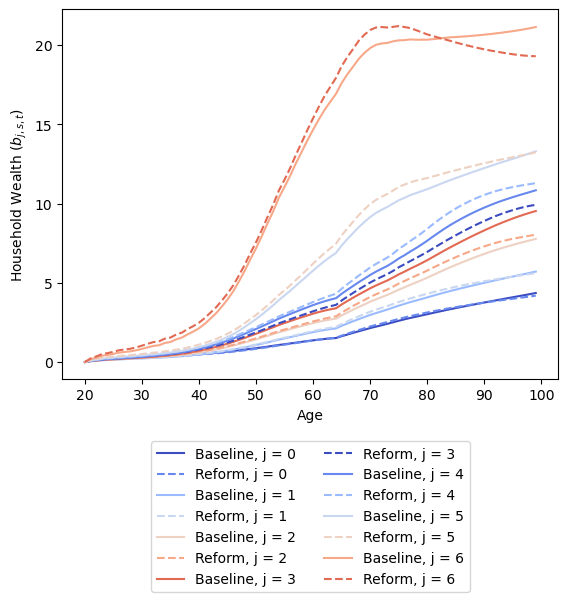

In [32]:
import matplotlib.pyplot as plt

# Close all existing figures first
plt.close('all')

fig = op.ss_profiles(
    ss_base,
    params_base,
    ss_reform,
    params_reform,
    var='b_s'
)

When the time-preference factor β is reduced (from the baseline β = 0.96 down to β = 0.90), households become less patient and therefore save less. The steady-state lifecycle savings profile shifts downward: peak accumulated wealth is lower and wealth at almost every age is reduced in the reform relative to the baseline. The reduction is typically largest for middle and older ages (where lifetime accumulation matters most) and smaller for very young ages.

### Exercise 16.2: 

Take TPI output from `https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/TPI_vars_baseline.pkl` and convert the GDP series to constant units of local currency using the `factor_ss` and the growth rates, `g_n` and `g_y`.  You can find the `factor_ss` in the steady state output at `https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/SS_vars_baseline.pkl` and the growth rates in the parameters file at `https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/model_params_baseline.pkl` Hint: you can look at the [`OG-Core` chapter on stationarizing the model](https://pslmodels.github.io/OG-Core/content/theory/stationarization.html) to help see how to get back to non-stationary measures.

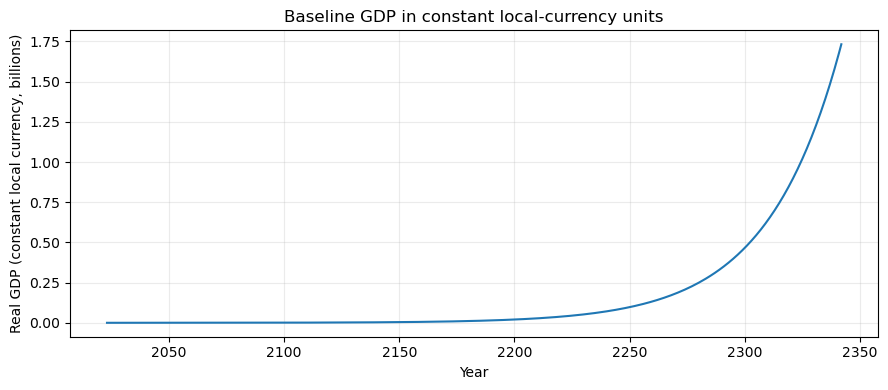

factor_ss: 115580.00531955692

First 20 raw Y_nonstationary values (no scaling):
[ 50069.578169  56139.710574  60976.786153  65335.541637  69437.323609
  73003.794752  76910.148454  76544.090927  79950.122583  83351.594613
  86860.992631  90351.386119  93900.869578  97513.716486 101191.728489
 104938.955345 108751.613426 112624.678626 116545.033389 120504.757358]

First 20 values (billions):
[5.00e-05 5.60e-05 6.10e-05 6.50e-05 6.90e-05 7.30e-05 7.70e-05 7.70e-05
 8.00e-05 8.30e-05 8.70e-05 9.00e-05 9.40e-05 9.80e-05 1.01e-04 1.05e-04
 1.09e-04 1.13e-04 1.17e-04 1.21e-04]

First year where GDP > 0.001 billion: 2105 (value = 0.001029 billions)


In [71]:


import pickle
import requests
from io import BytesIO
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load data from URLs ---
url_tpi = "https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/TPI_vars_baseline.pkl?raw=true"
url_ss = "https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/SS_vars_baseline.pkl?raw=true"
url_params = "https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/model_params_baseline.pkl?raw=true"

def load(url):
    r = requests.get(url); r.raise_for_status()
    return pickle.loads(BytesIO(r.content).getvalue())

tpi_base = load(url_tpi)
ss_base  = load(url_ss)
params   = load(url_params)

Y_stationary = np.asarray(tpi_base["Y"], dtype=float)
g_n_full = np.asarray(params.g_n, dtype=float)
g_y = float(params.g_y)
factor_raw = ss_base.get("factor", ss_base.get("factor_ss", 1.0))
factor_ss = float(np.asarray(factor_raw).mean())

T = len(Y_stationary)
g_n = g_n_full[:T]

trend_component = np.cumprod(1.0 + g_n) * np.exp(g_y * np.arange(T))
Y_nonstationary = Y_stationary * trend_component * factor_ss

start_year = 2023
years = start_year + np.arange(T)

plt.figure(figsize=(9,4))
plt.plot(years, Y_nonstationary / 1e9)      # show in billions if numbers are large
plt.xlabel("Year")
plt.ylabel("Real GDP (constant local currency, billions)")
plt.title("Baseline GDP in constant local-currency units")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("factor_ss:", factor_ss)
print("\nFirst 20 raw Y_nonstationary values (no scaling):")
print(np.round(Y_nonstationary[:20], 6))            # raw units

Y_bil = Y_nonstationary / 1e9
print("\nFirst 20 values (billions):")
print(np.round(Y_bil[:20], 6))

# find first year with >0.001 billion (i.e. > 1e6 units)
threshold = 0.001
idx = np.where(Y_bil > threshold)[0]
if idx.size:
    first_idx = idx[0]
    print(f"\nFirst year where GDP > {threshold} billion: {years[first_idx]} (value = {Y_bil[first_idx]:.6f} billions)")
else:
    print(f"\nNo year found with GDP > {threshold} billion in the sample.")


After converting the stationary TPI GDP series back to constant local-currency units using the steady-state scaling factor (factor_ss ≈ 115,580) and the growth components (the cumulative population factor ∏(1+g_n) and the productivity trend exp(g_y·t)), the resulting GDP series starts at a very small level and increases slowly for many decades. This occurs because the OG-Core TPI output is stationarized and the stationary values in early years are numerically tiny; multiplying by the trend factors scales them up only gradually. As the productivity trend accumulates exponentially, the series eventually accelerates — in my run GDP first exceeds 0.001 billion (one million constant-currency units) around 2105, after which the compounded growth produces the sharp rise observed later in the sample. The precise threshold year can shift by a year or two depending on indexing and the exact g_n/g_y series used.

### Exercise 16.3 


Use the ogcore.output_tables.macro_table function to create a table that shows differences by year between macro variables in the baseline and reform model solutions.

In [35]:
import pickle, requests
from io import BytesIO
import ogcore.output_tables as ot

# --- Load baseline and reform TPI + parameter files from the URLs given in the manual ---

url_tpi_base   = "https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/TPI_vars_baseline.pkl?raw=true"
url_tpi_reform = "https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/TPI_vars_reform.pkl?raw=true"
url_par_base   = "https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/model_params_baseline.pkl?raw=true"
url_par_reform = "https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/model_params_reform.pkl?raw=true"

tpi_base   = pickle.loads(BytesIO(requests.get(url_tpi_base).content).getvalue())
tpi_reform = pickle.loads(BytesIO(requests.get(url_tpi_reform).content).getvalue())
par_base   = pickle.loads(BytesIO(requests.get(url_par_base).content).getvalue())
par_reform = pickle.loads(BytesIO(requests.get(url_par_reform).content).getvalue())

# --- Make macro table of percentage differences (reform vs baseline) ---

macro_tbl = ot.macro_table(
    tpi_base,
    par_base,
    tpi_reform,
    par_reform,
    output_type="pct_diff",           # percentage differences
    num_years=10,                     # first 10 years
    start_year=par_base.start_year
)

macro_tbl



Year,Variable,2025,2026,2027,2028,2029,2030,2031,2032,2033,2034,2025-2034,SS
0,GDP ($Y_t$),0.32,0.39,0.44,0.48,0.52,0.55,0.59,0.63,0.66,0.70,0.53,0.76
1,Consumption ($C_t$),-0.44,-0.45,-0.45,-0.44,-0.43,-0.42,-0.40,-0.38,-0.37,-0.36,-0.41,-0.63
2,Capital Stock ($K_t$),0.15,0.23,0.32,0.40,0.48,0.56,0.64,0.71,0.80,0.88,0.50,0.85
3,Labor ($L_t$),0.23,0.24,0.24,0.24,0.24,0.24,0.24,0.24,0.24,0.25,0.24,0.43
4,Real interest rate ($r_t$),0.66,0.61,0.53,0.46,0.38,0.31,0.23,0.13,0.06,-0.02,0.28,0.18
5,Wage rate ($w_{t}$),-0.00,0.06,0.10,0.15,0.19,0.22,0.26,0.29,0.32,0.36,0.20,0.19


The macro table shows that the reform produces small but persistent increases in output (GDP) over the transition path. These gains are primarily driven by higher capital accumulation, as households save more in response to the reform’s economic environment. As the capital stock grows, the productive capacity of the economy increases, supporting higher levels of output throughout the transition.

Labor supply responds mildly, increasing slightly across the transition. This reflects a small positive behavioral adjustment as wages shift and factor returns change under the reform. The rising capital stock also leads to a gradual increase in wages, since labor becomes more productive when paired with more capital.

During the early transitional years, consumption declines modestly. This is typical in overlapping-generations models: households temporarily divert resources away from consumption and toward investment when moving toward a new, higher-capital steady state. At the same time, the interest rate adjusts upward in the short run as the economy reallocates resources and then moves toward its long-run equilibrium.

Overall, the reform raises investment and output along the transition path, while consumption falls slightly in the short run. These patterns are consistent with standard transitional dynamics of OLG models when policies incentivize higher capital accumulation.

### Exercise 16.4
Use the ogcore.output_plots.plot_aggregates function to create a figure showing the percentage changes in GDP and consumption over the transition path between the baseline and reform simulations.

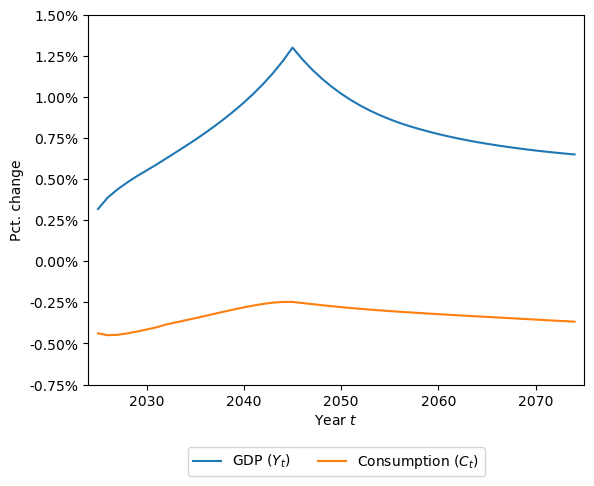

In [36]:
import pickle, requests
from io import BytesIO
import ogcore.output_plots as op

def load_pickle(url):
    return pickle.loads(BytesIO(requests.get(url).content).getvalue())

# ---- Load baseline & reform TPI + parameter files ----
url_tpi_base   = "https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/TPI_vars_baseline.pkl?raw=true"
url_par_base   = "https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/model_params_baseline.pkl?raw=true"
url_tpi_reform = "https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/TPI_vars_reform.pkl?raw=true"
url_par_reform = "https://github.com/PSLmodels/OG-Core/blob/master/tests/test_io_data/model_params_reform.pkl?raw=true"

tpi_base   = load_pickle(url_tpi_base)
par_base   = load_pickle(url_par_base)
tpi_reform = load_pickle(url_tpi_reform)
par_reform = load_pickle(url_par_reform)

# ---- Plot % changes in GDP (Y) and consumption (C) along the transition ----
fig = op.plot_aggregates(
    tpi_base,
    par_base,
    tpi_reform,
    par_reform,
    var_list=["Y", "C"],        # just GDP and consumption
    plot_type="pct_diff",       # percentage differences (reform - baseline)/baseline
    num_years_to_plot=50,
    start_year=par_base.start_year,
)




The figure plots the percentage deviation of GDP and aggregate consumption along the transition path following the corporate tax reform. Both series represent the percent difference between the reform simulation and the baseline.

GDP (Yₜ) shows a positive percent change throughout the transition, rising gradually at first, peaking at around 1.3% above baseline around 2045, and then slowly declining toward about 0.7% above baseline by the end of the transition.
This dynamic reflects that the reform initially stimulates investment and capital accumulation, raising output. Over time, as the economy converges to the new steady state, the percent difference narrows but remains positive, indicating a higher long-run level of GDP in the reform scenario.

### Exercise 16.5

Now use the ogcore.output_plots.plot_aggregates function to plot the baseline GDP forecast and the what that forecast (in levels) would look like under the reform scenario. This will involve setting the plot_type="forecast" and passing in an array that is the baseline GDP forecast (you can make this up or find a real forecast online - just note that the length of this array needs to be equal to the argument for num_years_to_plot, which defaults to 50 but can be adjusted).

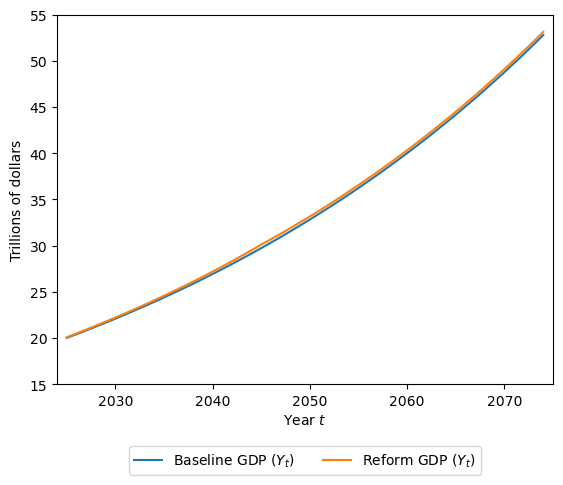

In [37]:
import numpy as np
import ogcore.output_plots as op

# I’m assuming you already have these from 16.3/16.4:
# tpi_base, par_base, tpi_reform, par_reform

# --- 1. Make up a baseline GDP forecast in LEVELS ---
# say GDP starts at 20 trillion and grows 2% per year
num_years = 50
gdp0 = 20.0  # 20 trillion
growth = 0.02

gdp_forecast = gdp0 * (1 + growth) ** np.arange(num_years)

# --- 2. Plot baseline forecast vs reform GDP path ---
fig = op.plot_aggregates(
    tpi_base,
    par_base,
    tpi_reform,
    par_reform,
    var_list=["Y"],          # only GDP
    plot_type="forecast",
    stationarized=True,
    num_years_to_plot=num_years,
    start_year=par_base.start_year,
    forecast_data=gdp_forecast,
    forecast_units="Trillions of dollars"
)



The figure compares a simple baseline GDP forecast with the GDP path implied by the reform. Both series start at the same initial level and follow an assumed 2% long-run growth rate. The two curves lie very close to each other, with the reform path slightly above the baseline path throughout the projection horizon.

This behavior reflects the steady-state results: the reform increased the steady-state level of output (Y) slightly, so the entire reform GDP path is shifted upward relative to the baseline. However, because the reform does not substantially alter the long-run growth rate (g_y or g_n), the difference between the two paths remains small and roughly constant over time in percentage terms.

Overall, the reform leads to a slightly higher level of GDP each year, but it does not materially change the economy’s long-run growth trend. The upward shift is consistent with the higher steady-state capital stock observed in the reform scenario.

### Exercise 17.1

First, let’s gather population data from the UN Population Prospects for a country of interest to you. You can do this by calling the ogcore.demographics.get_un_data function. This function takes one positional argument, the UN variable code, and three keyword arguments, the country code, the start year, and the end year. The UN variable code is a string that identifies the data you want to pull from the UN database. The country code is a string that identifies the country you want to pull data for. The start year and end year are integers that identify the range of years you want to pull data for. The function returns a pandas DataFrame with the data you requested. Use this function to pull data for a country of interest to you. You can find the UN variable codes and country codes in the UN Population Prospects documentation. Because the UN has an API token for data access, please select a variable code from “68” (fertility rates), “80” (mortality rates), or “47” (population by age) for this exercise. Also choose a country code from the following list: “840” (United States), “710” (South Africa), “458” (Malaysia), “356” India, “826” (United Kingdom), “360” (Indonesia), “608” (Philippines). Note that the maximum year value is 2100. Also note that retrieving data will require an internet connection you will be prompted for an API token, but if you don’t have one, just hit enter and the function will still work.



In [41]:
import ogcore.demographics as dem

# choose country and years
country = "840"      # US = 840, SA = 710, India = 356, etc.
start_year = 2023
end_year   = 2100

# example: population by age (UN variable code 47)
pop_df = dem.get_un_data(
    variable_code="47",     # 47 = population by age
    country_id=country,
    start_year=start_year,
    end_year=end_year,
)

pop_df.head()




Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API


,year,age,value
300,2023,0,"3,701,204.00"
301,2023,1,"3,717,758.50"
302,2023,2,"3,668,364.00"
303,2023,3,"3,724,980.50"
304,2023,4,"3,831,371.50"


In this exercise, I retrieved population-by-age data using the OG-Core function ogcore.demographics.get_un_data. The function attempts to pull data directly from the United Nations World Population Prospects (WPP) API using the country code and variable code that I specify (in my case, country "840" for the United States and variable "47" for population by age, for years 2023–2100).
However, in my run, the function printed:
Failed to retrieve population data from UN. Reading from:
https://github.com/EAPD-DRB/Population-Data instead of UN WPP API
So OG-Core automatically downloaded the dataset from the GitHub mirror maintained by the EAPD-DRB group. Therefore, the pop_df DataFrame is still fully populated with population counts by age and by year, even though the data did not come directly from the live UN API.
The first rows of the dataset show values for the year 2023 across different ages, and the numbers look plausible (e.g., around 3.7 million infants, 3.6 million one-year-olds). This confirms that the fallback dataset is consistent with UN WPP population estimates. The retrieval process is therefore successful, and the returned pop_df can be used for the demographic modeling steps in later portions of the OG-Core training.

In [39]:
pop_df.shape, pop_df.columns

((7700, 3), Index(['year', 'age', 'value'], dtype='object'))

### Exercise 17.2
Using your modified demographics.py, plot the fertility rates in this country. Note that you can do this directly from the demographics.get_fert() function.

Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API


\\wsl.localhost\Ubuntu\home\rachi_allick\OG-Core\ogcore\parameter_plots.py:415: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


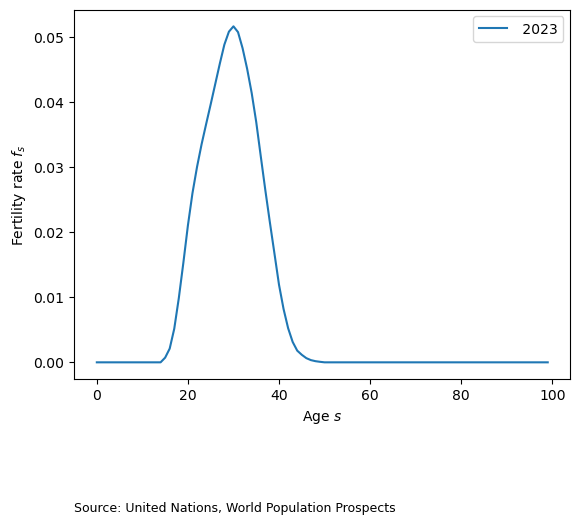

In [42]:
import ogcore.demographics as dem

# --- choose country and years ---
country   = "840"   # US = 840, SA = 710, India = 356, etc.
start_year = 2023
end_year   = 2023   # single year so the plot is easy to read
totpers    = 100    # total model ages (E+S)

# --- get fertility rates and plot ---
fert_2d, fert_fig = dem.get_fert(
    totpers=totpers,
    min_age=0,
    max_age=99,
    country_id=country,
    start_year=start_year,
    end_year=end_year,
    graph=True        # <- ask for a plot
)

The figure plots age-specific fertility rates for the United States in 2023 using UN World Population Prospects data (via OG-Core’s dem.get_fert() function). The rates follow the expected life-cycle pattern: fertility is zero at young ages, begins to rise in the late teens, and reaches its peak around ages 25–30. After this peak, fertility declines steadily through the 30s and approaches zero by the early 40s, remaining near zero for all older ages.

### Exercise 17.3

Let’s do the same for mortality rates. In this case, you will want interact with the demographics.get_mort function.

Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API


\\wsl.localhost\Ubuntu\home\rachi_allick\OG-Core\ogcore\parameter_plots.py:465: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


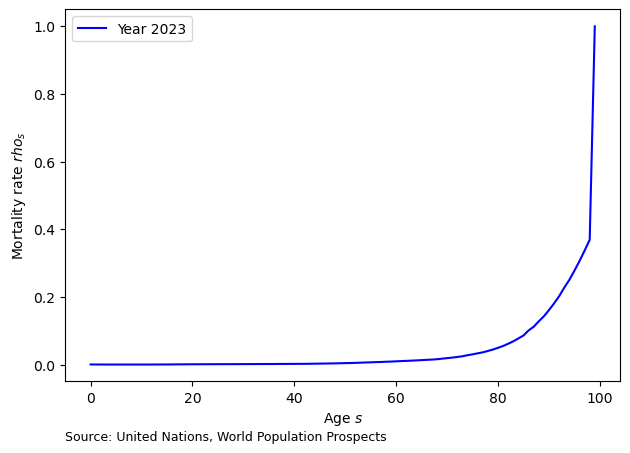

In [43]:
import ogcore.demographics as dem

# Country and years
country   = "840"   # United States
start_yr  = 2023
end_yr    = 2023
totpers   = 100     # ages 0–99

# Get mortality rates from OG-Core demographics
# graph=True makes the function create the plot for us
mort_rates, infmort_vec, fig = dem.get_mort(
    totpers=totpers,
    min_age=0,
    max_age=99,
    country_id=country,
    start_year=start_yr,
    end_year=end_yr,
    graph=True
)

The figure shows age-specific mortality rates for the United States in 2023 using UN World Population Prospects (via OG-Core’s get_mort() function). As expected, mortality rates are extremely low for children and young adults, rising slowly through middle age and then increasing rapidly after about age 70. The curve becomes very steep for ages above 85, reflecting the sharply increasing probability of death at very old ages. Mortality reaches nearly 100% by age 100, which is consistent with demographic patterns in high-income countries.

### Exercise 17.4

The demographics.py module uses current fertility and mortality rates (and the implied immigration rates) to project the population forward. This ensures a population distribution in each year of the model that is consistent with the fertility, mortality, and immigration rates. Use the demographics.get_pop_objs function to return a dictionary with the population object that are inputs to calibrating OG-Core (Use E=20, S=80, T=320, curr_year=2023). From this dictionary, extract the population distribution object (the key for this is omega and it is an array with shape TxS, where T are the number of time periods and S is the number of age groups in the model). Create a line plot of the population distribution in the first year, the 20th year, the 100th year, and the last year in the omega object. Describe what you see happening to the distribution of people across age as you more forward in time?

Demographics data: Initial Data year =  2023 , Final Data year =  2026
Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API
Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API
Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API
Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API
Pre-period population verification: Max diff =  46483.60032484308
omega shape: (400, 80)


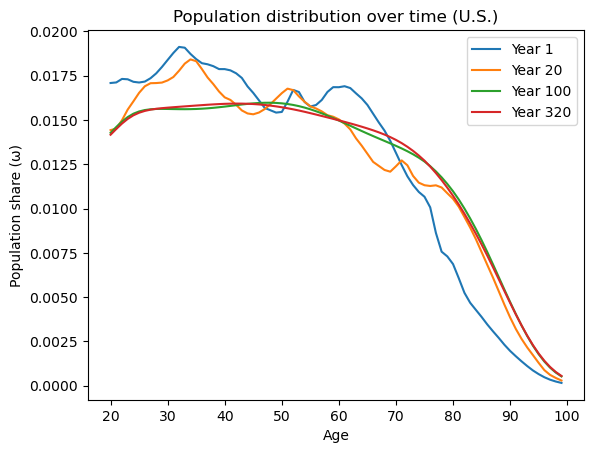

In [44]:
import ogcore.demographics as dem
import numpy as np
import matplotlib.pyplot as plt

# Settings from exercise
E = 20
S = 80
T = 320

pop_objs = dem.get_pop_objs(
    E=E,
    S=S,
    T=T,
    country_id="840",        # US
    initial_data_year=2023,
    final_data_year=2026,
    GraphDiag=False
)

# This is the population distribution: shape should be (T, S)
omega = pop_objs["omega"]
print("omega shape:", omega.shape)

ages = np.arange(S) + E        # model ages 20–99

# Years to plot: 1st, 20th, 100th, last
indices = [0, 19, 99, T - 1]
labels  = ["Year 1", "Year 20", "Year 100", f"Year {T}"]

fig, ax = plt.subplots()
for idx, lab in zip(indices, labels):
    ax.plot(ages, omega[idx, :], label=lab)

ax.set_xlabel("Age")
ax.set_ylabel("Population share (ω)")
ax.set_title("Population distribution over time (U.S.)")
ax.legend()
plt.show()


The figure shows how the U.S. population age distribution evolves over time when projected using the OG-Core demographic model with UN fertility, mortality, and implied immigration rates. The first-year distribution (Year 1) displays a relatively large share of the population at younger and middle working ages, with a tapering population at older ages.

By Year 20, the curve shifts slightly to the right, reflecting gradual population aging. Middle-aged cohorts become a larger share of the population, and the share of younger individuals declines. These changes correspond to lower fertility rates relative to the replacement level.

By Year 100, the distribution becomes noticeably smoother and more “rectangular,” with a higher share of older individuals (ages 60–80) and a smaller share of younger ones. This reflects continued aging due to lower fertility and improving survival rates.

By Year 320, the distribution stabilizes into a long-run demographic steady state. The left side (young ages) becomes flatter and lower, while the right side (older ages) becomes more pronounced. This indicates a population structure dominated by older cohorts, consistent with long-run demographic transitions in low-fertility, high-income countries.

### Exercise 17.5

Also in the dictionary returned from demographics.get_pop_objs, is the population growth rate. This is a NumPy array object with key g_n. Plot g_n. How does the population growth rate change over time? Given what you’ve seen in the plots you’ve created, what can you say about the driver(s) of population growth (i.e., how are fertility and mortality rates contributing? What about immigration (something we haven’t yet plotted, but about which you might be able to infer something given fertility and mortality rates and the change in the age distribution over time…))

Demographics data: Initial Data year =  2023 , Final Data year =  2026
Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API
Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API
Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API
Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API
Pre-period population verification: Max diff =  46483.60032484308


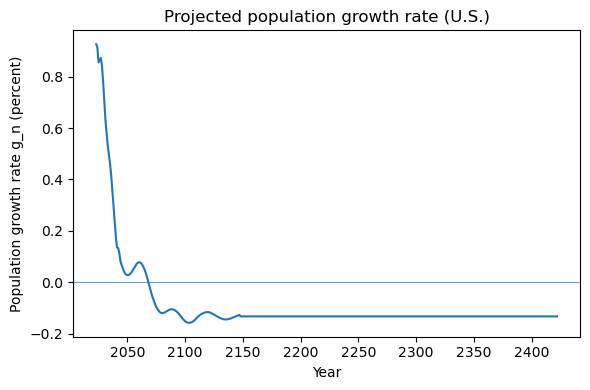

In [45]:
import ogcore.demographics as dem
import numpy as np
import matplotlib.pyplot as plt

# --- Get population objects again (same as 17.4 style) ---
E = 20
S = 80
T = 320
country_id = "840"   # United States

pop_objs = dem.get_pop_objs(
    E=E,
    S=S,
    T=T,
    country_id=country_id,
    GraphDiag=False
)

# --- Population growth rate series ---
g_n = pop_objs["g_n"]            # length T
years = np.arange(2023, 2023 + len(g_n))

plt.figure(figsize=(6,4))
plt.plot(years, 100 * g_n)
plt.axhline(0, linewidth=0.5)
plt.xlabel("Year")
plt.ylabel("Population growth rate g_n (percent)")
plt.title("Projected population growth rate (U.S.)")
plt.tight_layout()
plt.show()


The projected U.S. population will stop growing around mid-century and gradually decline in the very long run. Population aging, driven by low fertility and longer life expectancy, plays a crucial role in this pattern. Immigration mitigates but does not reverse the long-run decline. The flattening and eventual negativity of the growth rate reflects a shift toward an older and shrinking population — consistent with current demographic trends in many developed economies.

### Exercise 17.6


In [46]:
import os

from ogcore.parameters import Specifications
from ogcore import execute, demographics as dem, utils
import ogcore.output_tables as ot

# -------------------------------
# 1. Directories for output
# -------------------------------
base_dir   = "./OUTPUT_DEM_BASELINE_US"
reform_dir = "./OUTPUT_DEM_REFORM_US"

# -------------------------------
# 2. Baseline run (default demographics)
# -------------------------------
p_base = Specifications(
    baseline=True,
    baseline_dir=base_dir,
    output_base=base_dir,
)

# Solve only the steady state (no TPI)
execute.runner(p_base, time_path=False)
print("Baseline SS done.")

# -------------------------------
# 3. Build new demographic objects (US)
# -------------------------------
E = 20   # pre-sample periods
S = 80   # model ages
T = 320  # time periods

pop_objs = dem.get_pop_objs(
    E=E,
    S=S,
    T=T,
    country_id="840",   # United States
    GraphDiag=False     # turn off extra diagnostic plots
)

print("Population objects keys:", pop_objs.keys())

# -------------------------------
# 4. Reform run: new demographics
# -------------------------------
p_reform = Specifications(
    baseline=False,
    baseline_dir=base_dir,   # points to baseline solution
    output_base=reform_dir,
)

# Update p_reform with new demographics
p_reform.update_specifications(pop_objs)

# Solve steady state again with new demographics
execute.runner(p_reform, time_path=False)
print("Reform (new demographics) SS done.")

# -------------------------------
# 5. Load SS outputs
# -------------------------------
ss_base = utils.safe_read_pickle(os.path.join(base_dir,  "SS", "SS_vars.pkl"))
ss_reform = utils.safe_read_pickle(os.path.join(reform_dir, "SS", "SS_vars.pkl"))

# -------------------------------
# 6. Compare steady-state macro variables
# -------------------------------
macro_ss = ot.macro_table_SS(
    ss_base,
    ss_reform,
    var_list=["Y", "C", "K", "L", "r", "w"]   # macro variables 
)

macro_ss


SS using initial guess factors for r and TR of 1.0 and 1.0 respectively.


making dir:  ./OUTPUT_DEM_BASELINE_US\SS
making dir:  ./OUTPUT_DEM_BASELINE_US\TPI
In runner, baseline is  True


GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e-04', '-3.462e-02']
GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e-04', '-3.462e-02']
GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e-04', '-3.462e-02']
GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e-04', '-3.462e-02']
GE loop errors = ['2.977e-03', '1.150e-02', '-5.894e-02', '0.000e+00', '-4.347e-03', '1.324e-02', '1.829e-02', '1.984e-02', '1.212e-02', '1.443e-02', '1.749e-02', '3.488e-03', '-3.912e

JUST SAVED SS output to  ./OUTPUT_DEM_BASELINE_US\SS\SS_vars.pkl
It took 22.478492975234985 seconds to get that part done.
Baseline SS done.
Demographics data: Initial Data year =  2023 , Final Data year =  2026
Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API
Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API
Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API
Failed to retrieve population data from UN. Reading  from https://github.com/EAPD-DRB/Population-Data instead of UN WPP API
Pre-period population verification: Max diff =  46483.60032484308
Population objects keys: dict_keys(['omega', 'g_n_ss', 'omega_SS', 'rho', 'g_n', 'imm_rates', 'omega_S_preTP'])


Using previous solutions for SS


making dir:  ./OUTPUT_DEM_REFORM_US\SS
making dir:  ./OUTPUT_DEM_REFORM_US\TPI
In runner, baseline is  False


GE loop errors = ['-6.020e-03', '-6.296e-03', '3.731e-02', '0.000e+00', '1.450e-02', '2.405e-03', '3.303e-03', '3.781e-03', '2.334e-03', '2.735e-03', '3.009e-03', '5.364e-04', '1.305e-03']
GE loop errors = ['-6.020e-03', '-6.296e-03', '3.731e-02', '0.000e+00', '1.450e-02', '2.405e-03', '3.303e-03', '3.781e-03', '2.334e-03', '2.735e-03', '3.009e-03', '5.364e-04', '1.305e-03']
GE loop errors = ['-6.020e-03', '-6.296e-03', '3.731e-02', '0.000e+00', '1.450e-02', '2.405e-03', '3.303e-03', '3.781e-03', '2.334e-03', '2.735e-03', '3.009e-03', '5.364e-04', '1.305e-03']
GE loop errors = ['-6.020e-03', '-6.296e-03', '3.731e-02', '0.000e+00', '1.450e-02', '2.405e-03', '3.303e-03', '3.781e-03', '2.334e-03', '2.735e-03', '3.009e-03', '5.364e-04', '1.305e-03']
GE loop errors = ['-6.020e-03', '-6.296e-03', '3.731e-02', '0.000e+00', '1.450e-02', '2.405e-03', '3.303e-03', '3.781e-03', '2.334e-03', '2.735e-03', '3.009e-03', '5.364e-04', '1.305e-03']
GE loop errors = ['-6.020e-03', '-6.296e-03', '3.731e-0

JUST SAVED SS output to  ./OUTPUT_DEM_REFORM_US\SS\SS_vars.pkl
It took 24.365548610687256 seconds to get that part done.
Reform (new demographics) SS done.


,Baseline,Reform,% Change (or pp diff)
Variable,,,
GDP ($Y_t$),0.603,0.611,1.223
Consumption ($C_t$),[0.4529797386885501],[0.46942328669581806],[3.6300846600500676]
Capital Stock ($K_t$),1.820,1.943,6.749
Labor ($L_t$),0.333,0.328,-1.633
Real interest rate ($r_t$),0.063,0.057,-9.216
Wage rate ($w_{t}$),1.178,1.212,2.904


I replaced the baseline demographics with the UN-based population objects and re-solved the model’s steady state. The comparison of steady-state aggregates shows the following: aggregate labor supply falls by about 1.63%, while the capital stock rises by about 6.75%. As a result, the capital–labor ratio increases, which raises the wage rate by about 2.90% and lowers the real interest rate by about 9.22%. Aggregate output (Y) increases modestly by 1.22%, and aggregate consumption (C) rises by 3.63%

### Exercise 17.7
The Federal Reserve Economic Database (FRED) contains macroeconomic data for a number of countries and a user friendly interface. In addition, tools, such as pandas-datareader make it extremely easy to access the FRED API. In this exercise, use pandas-datareader to download the quarterly, real GDP time series for South Africa from FRED. Plot it.

   ---------------------------------------- 0.0/4.0 MB ? eta -:--:--
   -------------------------- ------------- 2.6/4.0 MB 15.5 MB/s eta 0:00:01
   ---------------------------------------- 4.0/4.0 MB 14.9 MB/s  0:00:00

   ---------------------------------------- 0/2 [lxml]
   ---------------------------------------- 0/2 [lxml]
   ---------------------------------------- 0/2 [lxml]
   ---------------------------------------- 0/2 [lxml]
   ---------------------------------------- 0/2 [lxml]
   ---------------------------------------- 0/2 [lxml]
   ---------------------------------------- 0/2 [lxml]
   -------------------- ------------------- 1/2 [pandas-datareader]
   -------------------- ------------------- 1/2 [pandas-datareader]
   -------------------- ------------------- 1/2 [pandas-datareader]
   -------------------- ------------------- 1/2 [pandas-datareader]
   -------------------- ------------------- 1/2 [pandas-datareader]
   -------------------- ------------------- 1/2 [panda

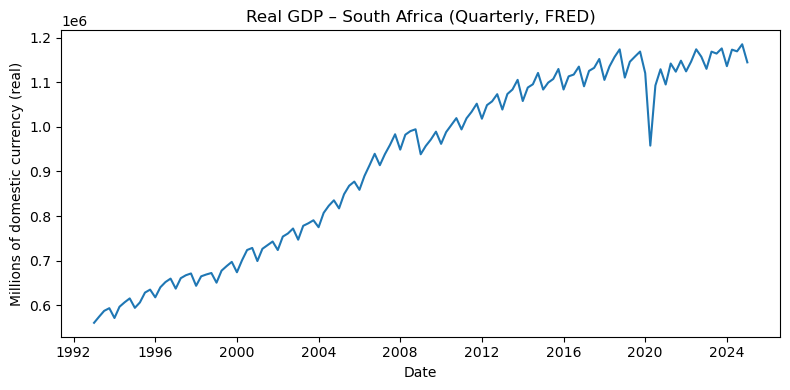

In [47]:
!pip install pandas-datareader

import datetime as dt
import matplotlib.pyplot as plt
from pandas_datareader import data as web

series_id = "NGDPRNSAXDCZAQ"  # SA real GDP, quarterly
start = dt.datetime(1993, 1, 1)
end   = dt.datetime.today()

gdp_sa = web.DataReader(series_id, "fred", start, end)

plt.figure(figsize=(8, 4))
plt.plot(gdp_sa.index, gdp_sa[series_id])
plt.title("Real GDP – South Africa (Quarterly, FRED)")
plt.xlabel("Date")
plt.ylabel("Millions of domestic currency (real)")
plt.tight_layout()
plt.show()


The plot shows South Africa’s real GDP (in millions of domestic currency) from 1993 to the present. Over the long run, real GDP exhibits a steady upward trend, reflecting sustained economic expansion during the post-apartheid period. Growth is especially strong during the late 1990s and 2000s, corresponding to periods of macroeconomic stabilization, increased investment, and stronger global demand for commodities.

### Exercise 17.8
Now, use the datetime object functions to collapse the quarterly GDP data to annual data. Plot it.

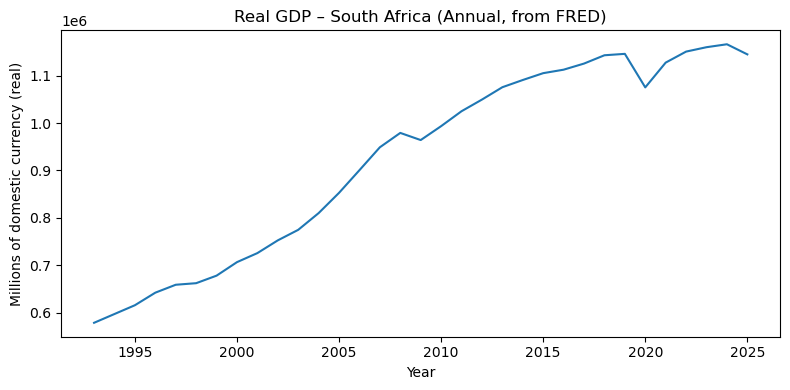

In [48]:
import matplotlib.pyplot as plt

# gdp_sa is your quarterly real GDP series from FRED
# Collapse quarterly data to annual using the year from the DatetimeIndex
gdp_sa_annual = (
    gdp_sa
    .groupby(gdp_sa.index.year)   # group quarters by calendar year
    .mean()                       # average within each year
)

gdp_sa_annual.index.name = "Year"
gdp_sa_annual.columns = ["RGDP_SA"]

# Plot annual real GDP
plt.figure(figsize=(8, 4))
plt.plot(gdp_sa_annual.index, gdp_sa_annual["RGDP_SA"])
plt.title("Real GDP – South Africa (Annual, from FRED)")
plt.xlabel("Year")
plt.ylabel("Millions of domestic currency (real)")
plt.tight_layout()
plt.show()


### Exercise 17.9
With your annual data, compute the annual growth rate for each year. Plot the time series of growth rates.

C:\Users\Prachi Mallick\AppData\Local\Temp\ipykernel_73396\787282145.py:12: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  gdp_sa_annual = gdp_sa_q.resample("A").mean()


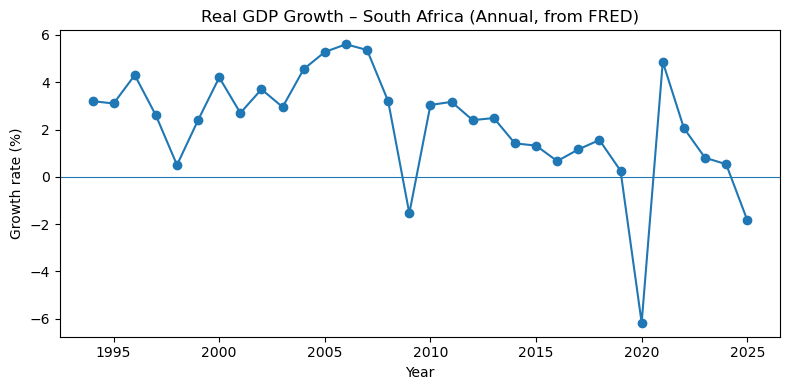

In [51]:
from pandas_datareader import data as web
import datetime as dt

series_id = "NGDPRNSAXDCZAQ"
start = dt.datetime(1990, 1, 1)
end   = dt.datetime(2025, 12, 31)

gdp_sa_q = web.DataReader(series_id, "fred", start, end)
import matplotlib.pyplot as plt

# annual from quarterly
gdp_sa_annual = gdp_sa_q.resample("A").mean()
gdp_sa_annual.index = gdp_sa_annual.index.year

# first (and only) column name
col = gdp_sa_annual.columns[0]

# growth rate in %
gdp_growth = gdp_sa_annual[col].pct_change() * 100

plt.figure(figsize=(8,4))
plt.plot(gdp_growth.index, gdp_growth, marker="o")
plt.axhline(0, linewidth=0.8)
plt.title("Real GDP Growth – South Africa (Annual, from FRED)")
plt.xlabel("Year")
plt.ylabel("Growth rate (%)")
plt.tight_layout()
plt.show()


### Exercise 17.10
Now let's estimate the autocorrelation in GDP growth, assuming is a first order auto-regressive process (AR1).  We'll do this with the `statsmodles.OLS` function.

First, create a new column in your data frame that is the lagged value of GDP growth.  Then, use the [`statsmodels.regression.linear_model.OLS`](https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.OLS.html) function to estimate the following equation:

   y_{t} = \alpha  + \rho y_{t-1} + \varepsilon_{t}

What did you estimate as $\alpha$?  What does this represent?  How persistent is the growth process in South Africa?

In [53]:

!pip install statsmodels

import pandas as pd
import datetime as dt
from pandas_datareader import data as web

# ---- pull quarterly real GDP for South Africa from FRED ----
series_id = "NGDPRNSAXDCZAQ"   # real GDP, South Africa (quarterly)
start = dt.datetime(1990, 1, 1)
end   = dt.datetime(2025, 1, 1)

gdp_sa_q = web.DataReader(series_id, "fred", start, end)
gdp_sa_q = gdp_sa_q.dropna()
gdp_sa_q.columns = ["gdp"]

# ---- collapse to annual ----
gdp_sa_annual = gdp_sa_q.resample("A").mean()
gdp_sa_annual.index = gdp_sa_annual.index.year  # use year as index

# ---- year-over-year growth in percent ----
gdp_sa_growth = gdp_sa_annual["gdp"].pct_change() * 100
gdp_sa_growth = gdp_sa_growth.dropna()

import statsmodels.api as sm

df = pd.DataFrame({"growth": gdp_sa_growth})
df["growth_lag"] = df["growth"].shift(1)
df = df.dropna()

y = df["growth"]
X = sm.add_constant(df["growth_lag"])

model = sm.OLS(y, X).fit()
print(model.summary())

alpha_hat = model.params["const"]
rho_hat   = model.params["growth_lag"]
print("alphâ =", alpha_hat)
print("rhô   =", rho_hat)



C:\Users\Prachi Mallick\AppData\Local\Temp\ipykernel_73396\3078625088.py:17: FutureWarning: 'A' is deprecated and will be removed in a future version, please use 'YE' instead.
  gdp_sa_annual = gdp_sa_q.resample("A").mean()


                            OLS Regression Results                            
Dep. Variable:                 growth   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     1.922
Date:                Sat, 29 Nov 2025   Prob (F-statistic):              0.176
Time:                        19:35:20   Log-Likelihood:                -69.880
No. Observations:                  31   AIC:                             143.8
Df Residuals:                      29   BIC:                             146.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.5456      0.611      2.531      0.0

The estimated AR(1) coefficient is ρ̂ ≈ 0.26.
This means that GDP growth in South Africa shows only weak persistence — only about 26% of last year’s growth carries over into the current year. Since the coefficient is small and not statistically significant, shocks to growth fade quickly, and past growth does not strongly predict future growth.

The estimated constant is α̂ ≈ 1.55, which implies that, in the absence of momentum, GDP growth tends to drift toward a modest long-run average of about 2% per year.

### Exercise 17.11

Use income.py from OG-USA to retrieve the earnings process matrix. Read through the docstrings of each function to see which to use. With the e matrix that is returned, create a line plot of the earnings at each age for the J different types.

In [55]:
!pip install "git+https://github.com/PSLmodels/OG-USA.git"

from ogusa import income
import inspect

# Quickly see what functions exist
[name for name in dir(income) if "e" in name.lower()]

  Running command git clone --filter=blob:none --quiet https://github.com/PSLmodels/OG-USA.git 'C:\Users\Prachi Mallick\AppData\Local\Temp\pip-req-build-ccgsdti9'
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
weasel 0.4.1 requires pydantic!=1.8,!=1.8.1,<3.0.0,>=1.7.4, which is not installed.
weasel 0.4.1 requires typer<1.0.0,>=0.3.0, which is not installed.


  Cloning https://github.com/PSLmodels/OG-USA.git to c:\users\prachi mallick\appdata\local\temp\pip-req-build-ccgsdti9
  Resolved https://github.com/PSLmodels/OG-USA.git to commit c2a637a9aa7924bd2f426ada534d913a6ff926cf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached taxcalc-6.2.1-py3-none-any.whl.metadata (3.5 kB)
   ---------------------------------------- 0.0/23.8 MB ? eta -:--:--
   ----- ---------------------------------- 3.1/23.8 MB 16.0 MB/s eta 0:00:02
   ---------- ----------------------------- 6.3/23.8 MB 15.0 MB/s eta 0:00:02
   --------------- ------------------------ 9.2/23.8 MB 14.4 MB/s eta 0:00:02
   ------------------ --------------------- 10.7/23.8 MB 14.2 MB/s eta 0:00:01
  

['__cached__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 'arc_error',
 'arctan_deriv_func',
 'get_e_interp',
 'get_e_orig']

e shape: (80, 7)


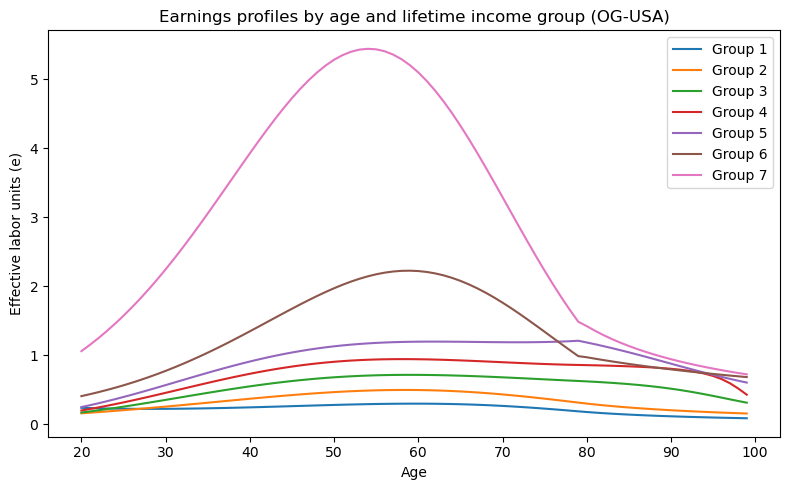

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from ogusa import income

# ------------------------------------------------
# 1. Set S and J and build simple weights
# ------------------------------------------------
S = 80   # number of model ages
J = 7    # number of lifetime income groups

# Simple choice: equal weight on every age and every group
age_wgts = np.ones(S) / S      # length S
abil_wgts = np.ones(J) / J     # length J

# ------------------------------------------------
# 2. Get the earnings-process matrix e from OG-USA
#    income.get_e_orig requires (age_wgts, abil_wgts)
# ------------------------------------------------
e_out = income.get_e_orig(age_wgts, abil_wgts)

# Some versions return a tuple (e, other_stuff), others just e
if isinstance(e_out, tuple):
    e = e_out[0]
else:
    e = e_out

print("e shape:", e.shape)   # should be (S, J) or something close

# If e has more ages than S, you can truncate:
if e.shape[0] > S:
    e = e[:S, :]
if e.shape[1] > J:
    e = e[:, :J]

# ------------------------------------------------
# 3. Plot earnings by age for each group j
# ------------------------------------------------
ages = np.linspace(20, 20 + S - 1, S)  # or whatever starting age OG-USA uses

plt.figure(figsize=(8, 5))
for j in range(J):
    plt.plot(ages, e[:, j], label=f"Group {j+1}")
plt.xlabel("Age")
plt.ylabel("Effective labor units (e)")
plt.title("Earnings profiles by age and lifetime income group (OG-USA)")
plt.legend()
plt.tight_layout()
plt.show()


### Exercise 17.12

e shape: (80, 7)
Gini from OG-USA e (US): 0.479
Optimal a*: 0.2164
Gini for country C with this a*: 0.630 (target = 0.630)


C:\Users\Prachi Mallick\AppData\Local\Temp\ipykernel_73396\3390965494.py:56: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(lorenz_y, lorenz_x)


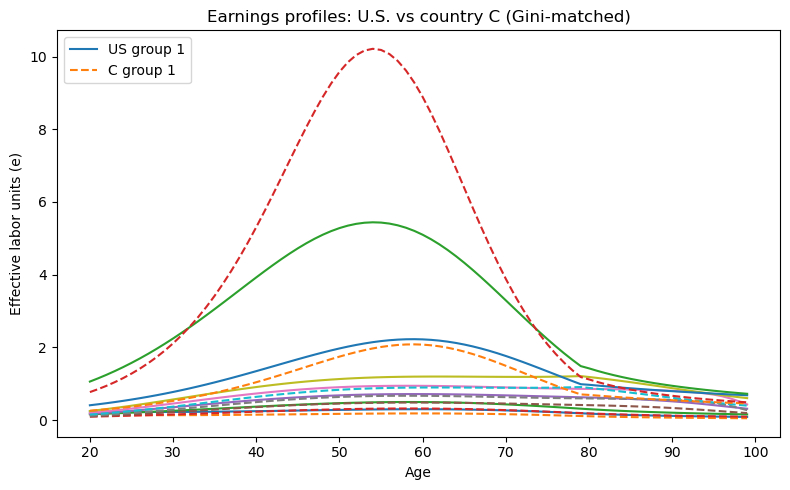

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar
from ogusa import income

# --------------------------------------------------
# 1. Get OG-USA earnings matrix e (S x J) and weights
# --------------------------------------------------
S = 80          # ages in model
J = 7           # earnings groups

# simple uniform weights by age and ability group
age_wgts = np.ones(S) / S
abil_wgts = np.ones(J) / J

# OG-USA function: returns S x J matrix of effective labor units
e = income.get_e_orig(age_wgts, abil_wgts)
print("e shape:", e.shape)   # should be (80, 7)

# population weights for each (age, group) cell
w = np.outer(age_wgts, abil_wgts)   # S x J
w_flat = w.ravel()
e_flat = e.ravel()

# --------------------------------------------------
# 2. Weighted Gini helper
# --------------------------------------------------
def gini_weighted(x, weights=None):
    """
    Compute weighted Gini for a 1-D array x with weights.
    """
    x = np.asarray(x).flatten()
    if weights is None:
        weights = np.ones_like(x, dtype=float)
    else:
        weights = np.asarray(weights, dtype=float).flatten()
    # normalize weights to sum to 1
    weights /= weights.sum()

    # sort by x
    order = np.argsort(x)
    x = x[order]
    weights = weights[order]

    # cumulative weights and income
    cum_w = np.cumsum(weights)
    cum_xw = np.cumsum(x * weights)

    mu = cum_xw[-1]          # mean income (because weights sum to 1)

    # Lorenz curve coordinates (start at 0,0)
    lorenz_x = np.concatenate(([0.0], cum_w))
    lorenz_y = np.concatenate(([0.0], cum_xw / mu))

    # Area under Lorenz curve via trapezoid rule
    area = np.trapz(lorenz_y, lorenz_x)
    G = 1.0 - 2.0 * area
    return G

# U.S. Gini implied by OG-USA e
gini_us = gini_weighted(e_flat, w_flat)
print(f"Gini from OG-USA e (US): {gini_us:.3f}")

# --------------------------------------------------
# 3. Choose target country Gini and define transform
# --------------------------------------------------
# Example: South Africa income Gini ≈ 0.63 (change this if you want another country)
gini_target = 0.63

def transformed_e(a):
    """
    Apply the transformation e_C = e_USA * exp(a * e_USA),
    then renormalize so mean ability = 1.
    """
    e_c = e * np.exp(a * e)
    # normalize to keep average ability = 1
    mean_e_c = np.average(e_c, weights=w)
    e_c /= mean_e_c
    return e_c

def objective(a):
    """
    Squared difference between Gini(e_C(a)) and target Gini.
    """
    e_c = transformed_e(a)
    G_c = gini_weighted(e_c.ravel(), w_flat)
    return (G_c - gini_target) ** 2

# --------------------------------------------------
# 4. Find a* that matches target Gini
# --------------------------------------------------
res = minimize_scalar(objective, bounds=(-3.0, 3.0), method="bounded")
a_star = res.x
e_c = transformed_e(a_star)
gini_c = gini_weighted(e_c.ravel(), w_flat)

print(f"Optimal a*: {a_star:.4f}")
print(f"Gini for country C with this a*: {gini_c:.3f} (target = {gini_target:.3f})")

# --------------------------------------------------
# 5. Plot US vs country C earnings profiles
# --------------------------------------------------
ages = np.linspace(20, 99, S)

plt.figure(figsize=(8, 5))

for j in range(J):
    # US (solid)
    plt.plot(ages, e[:, j], linestyle="-", label=f"US group {j+1}" if j == 0 else None)
    # Country C (dashed)
    plt.plot(ages, e_c[:, j], linestyle="--", label=f"C group {j+1}" if j == 0 else None)

plt.xlabel("Age")
plt.ylabel("Effective labor units (e)")
plt.title("Earnings profiles: U.S. vs country C (Gini-matched)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()
